<a href="https://colab.research.google.com/github/Adityanarayanjh/Corrosion_Rate/blob/main/mse656_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_excel("Corrosion_Raw_Uncleaned_3000.xlsx")
df.head()


,sample_id,material,environment,coating,%Cr,%Ni,%Mo,%C,%Mn,%Si,...,PREN,Cr_Ni_ratio,log_chloride,marine_severity_index,relative_resistance_index,corrosion_rate_mm_per_year,risk_level,source_reference,_Unnamed_,Notes
0,N0802,AISI444,Soil,No,16.540095,15.000000,2.381767,0.031064,0.577209,0.741409,...,26.664167,1.102673,10.693651,6.627951,2.280226,1.1966,High,Soil Corrosion Study (2024),-,temp adjustment
1,N0191,AISI410,marin,No,16.802068,0.475785,3.027630,0.083193,1.439811,0.471953,...,29.680084,35.314311,9.952945,6.269449,2.709781,1.5072,High,Soil Corrosion Study (2024),-,corrosion check
2,N0818,AISI444,Marine,Yes,21.836376,8.956516,1.217373,0.016021,1.183271,0.679382,...,26.732190,2.438043,10.376772,6.613532,2.349717,0.4585,Moderate,Corrosion Handbook CSV,check,corrosion check
3,S0252,Duplex2205,Atmospheric,No,24.532226,8.492710,2.448220,0.044766,1.022150,0.680384,...,32.838143,2.888621,9.638189,6.123621,3.086817,1.0314,High,Soil Corrosion Study (2024),-,verify
4,N1506,AISI304,Marine,Yes,16.776775,1.448785,3.663215,0.010000,1.629560,0.663917,...,30.385249,11.579885,9.847522,6.230331,2.801124,0.2322,Moderate,Atlas Steels Datasheet,-,NaN


<Axes: ylabel='corrosion_rate_mm_per_year'>

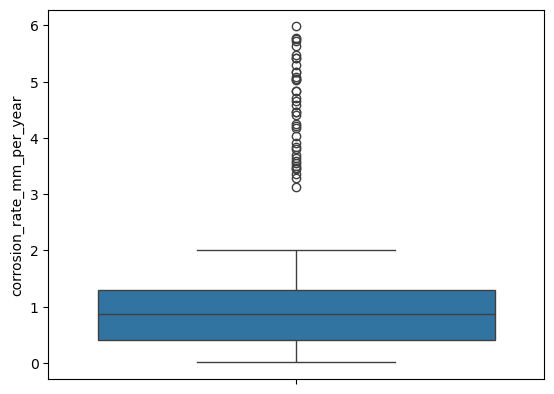

In [ ]:
import seaborn as sns
sns.boxplot(df['corrosion_rate_mm_per_year'])


Q1 = 0.41165
Q3 = 1.293425
IQR = 0.881775
Lower bound = -0.9110124999999998
Upper bound = 2.6160875
Number of outliers: 40


<Axes: xlabel='corrosion_rate_mm_per_year'>

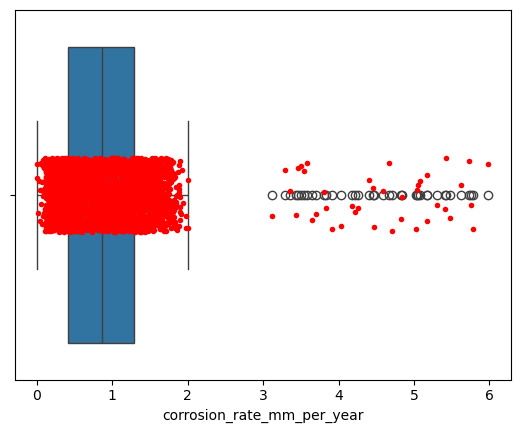

In [ ]:
Q1 = df['corrosion_rate_mm_per_year'].quantile(0.25)
Q3 = df['corrosion_rate_mm_per_year'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower bound =", lower_bound)
print("Upper bound =", upper_bound)


outliers = df[(df['corrosion_rate_mm_per_year'] < lower_bound) |
              (df['corrosion_rate_mm_per_year'] > upper_bound)]

print("Number of outliers:", len(outliers))
outliers[['sample_id', 'material', 'environment', 'corrosion_rate_mm_per_year']]

sns.boxplot(x=df['corrosion_rate_mm_per_year'])
sns.stripplot(x=df['corrosion_rate_mm_per_year'], color='red', size=4, jitter=True)


# DATA WRANGLING


In [ ]:
df.info()
df.describe()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sample_id                   3000 non-null   object 
 1   material                    3000 non-null   object 
 2   environment                 3000 non-null   object 
 3   coating                     3000 non-null   object 
 4   %Cr                         2768 non-null   float64
 5   %Ni                         3000 non-null   float64
 6   %Mo                         2762 non-null   float64
 7   %C                          3000 non-null   float64
 8   %Mn                         3000 non-null   float64
 9   %Si                         3000 non-null   float64
 10  %Cu                         3000 non-null   float64
 11  %N                          3000 non-null   float64
 12  temperature_C               3000 non-null   float64
 13  chloride_ppm                2760 

,sample_id,material,environment,coating,%Cr,%Ni,%Mo,%C,%Mn,%Si,...,PREN,Cr_Ni_ratio,log_chloride,marine_severity_index,relative_resistance_index,corrosion_rate_mm_per_year,risk_level,source_reference,_Unnamed_,Notes
0,N0802,AISI444,Soil,No,16.540095,15.000000,2.381767,0.031064,0.577209,0.741409,...,26.664167,1.102673,10.693651,6.627951,2.280226,1.1966,High,Soil Corrosion Study (2024),-,temp adjustment
1,N0191,AISI410,marin,No,16.802068,0.475785,3.027630,0.083193,1.439811,0.471953,...,29.680084,35.314311,9.952945,6.269449,2.709781,1.5072,High,Soil Corrosion Study (2024),-,corrosion check
2,N0818,AISI444,Marine,Yes,21.836376,8.956516,1.217373,0.016021,1.183271,0.679382,...,26.732190,2.438043,10.376772,6.613532,2.349717,0.4585,Moderate,Corrosion Handbook CSV,check,corrosion check
3,S0252,Duplex2205,Atmospheric,No,24.532226,8.492710,2.448220,0.044766,1.022150,0.680384,...,32.838143,2.888621,9.638189,6.123621,3.086817,1.0314,High,Soil Corrosion Study (2024),-,verify
4,N1506,AISI304,Marine,Yes,16.776775,1.448785,3.663215,0.010000,1.629560,0.663917,...,30.385249,11.579885,9.847522,6.230331,2.801124,0.2322,Moderate,Atlas Steels Datasheet,-,NaN


In [ ]:
df.isna().sum().sort_values(ascending=False)


_Unnamed_                     980
Notes                         746
pH                            245
chloride_ppm                  240
%Mo                           238
%Cr                           232
resistivity_ohm_m             225
coating                         0
exposure_days                   0
environment                     0
source_reference                0
risk_level                      0
corrosion_rate_mm_per_year      0
relative_resistance_index       0
marine_severity_index           0
log_chloride                    0
Cr_Ni_ratio                     0
PREN                            0
flow_rate_m_s                   0
relative_humidity_%             0
material                        0
temperature_C                   0
%N                              0
%Cu                             0
%Si                             0
%Mn                             0
%C                              0
%Ni                             0
sample_id                       0
dtype: int64

In [ ]:
df['environment'].value_counts(dropna=False)
df['coating'].value_counts()


coating
No     2110
Yes     890
Name: count, dtype: int64

<Axes: xlabel='corrosion_rate_mm_per_year'>

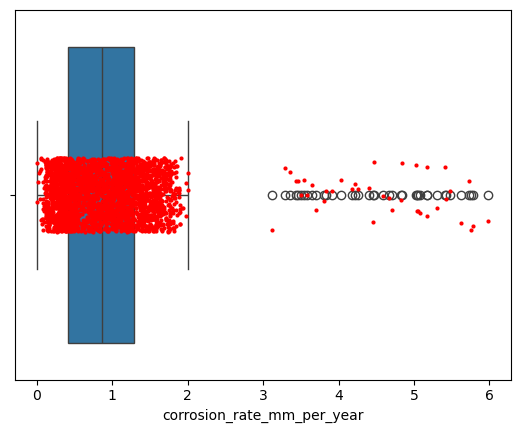

In [ ]:
sns.boxplot(x=df['corrosion_rate_mm_per_year'])
sns.stripplot(x=df['corrosion_rate_mm_per_year'], color='red', size=3, jitter=True)


 PHASE 2

In [ ]:
pip install missingno


Note: you may need to restart the kernel to use updated packages.


<Axes: >

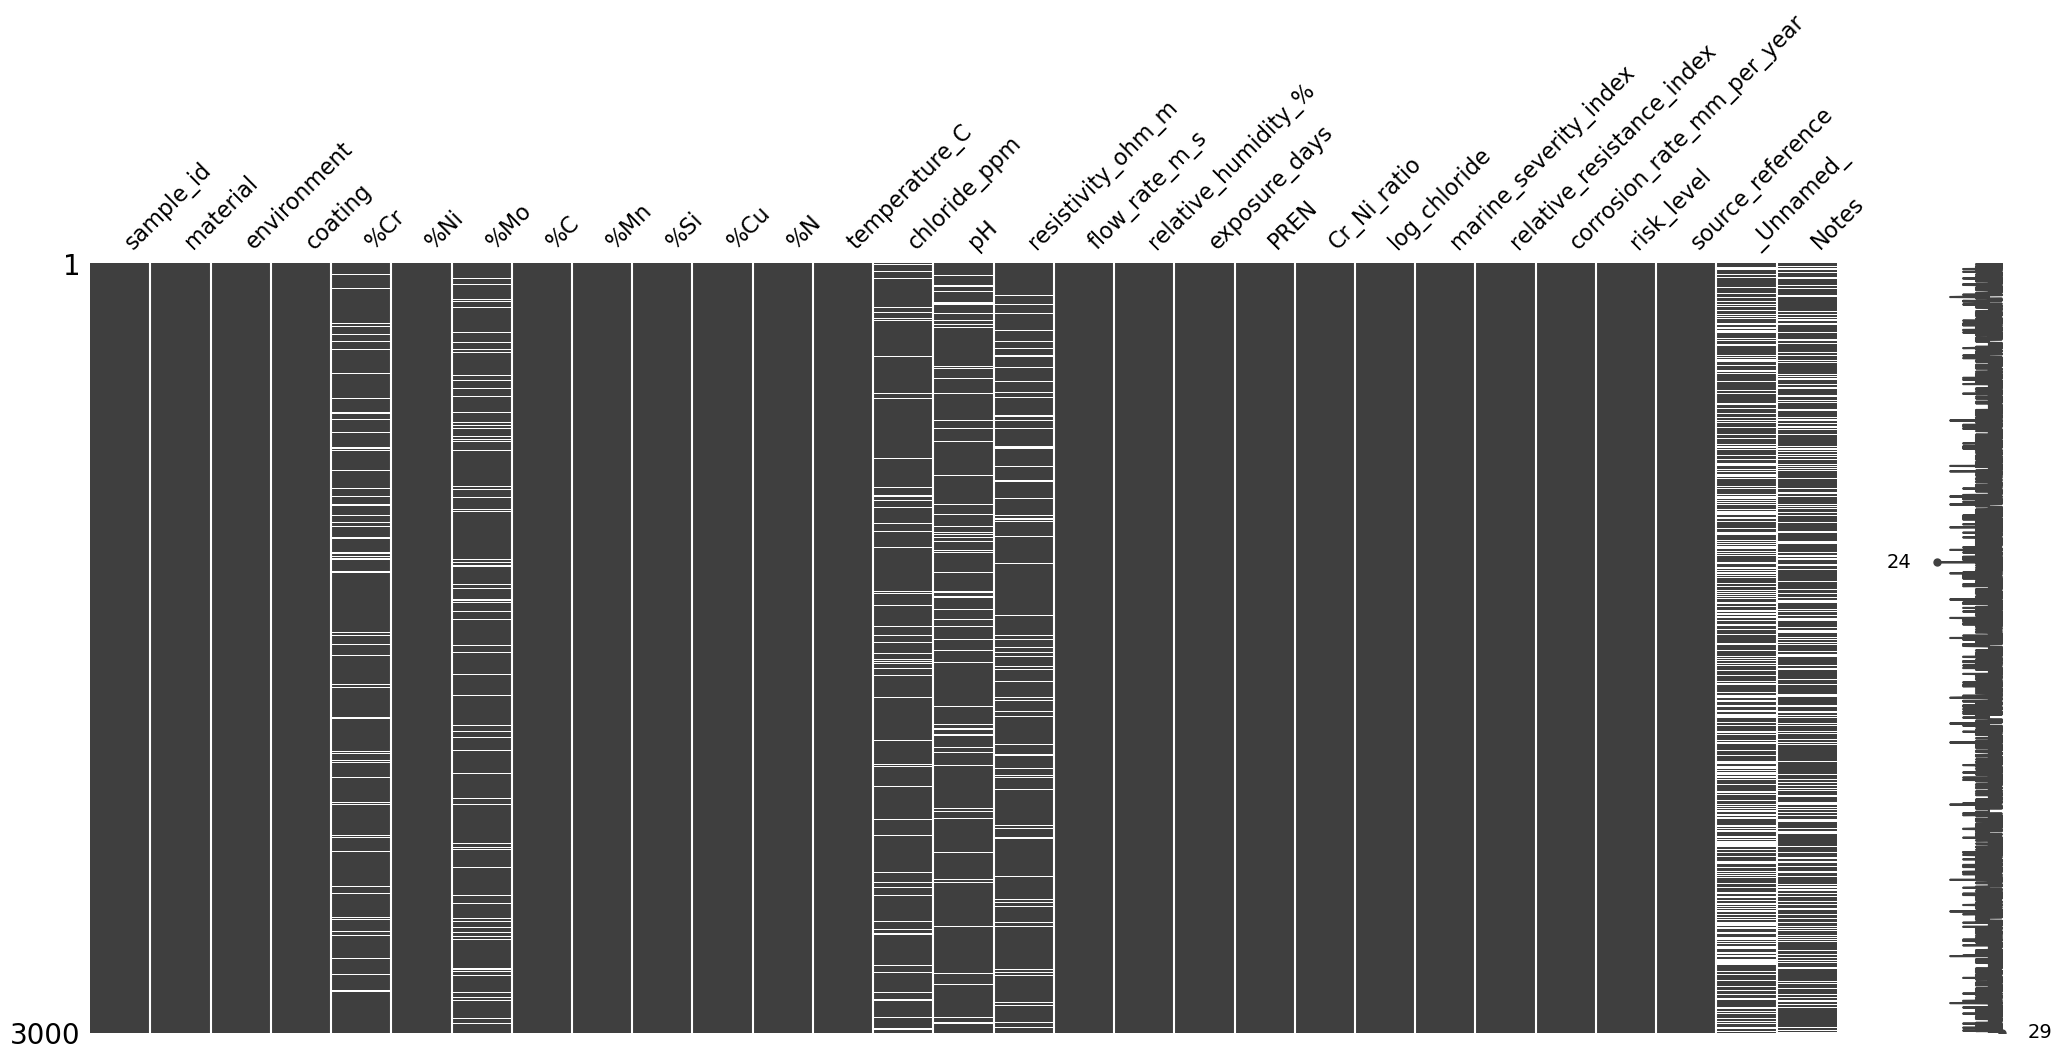

In [ ]:
import missingno as msno
raw_df = df.copy()

msno.matrix(df)


In [ ]:
# Replace empty strings and whitespace-only cells with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

<Axes: >

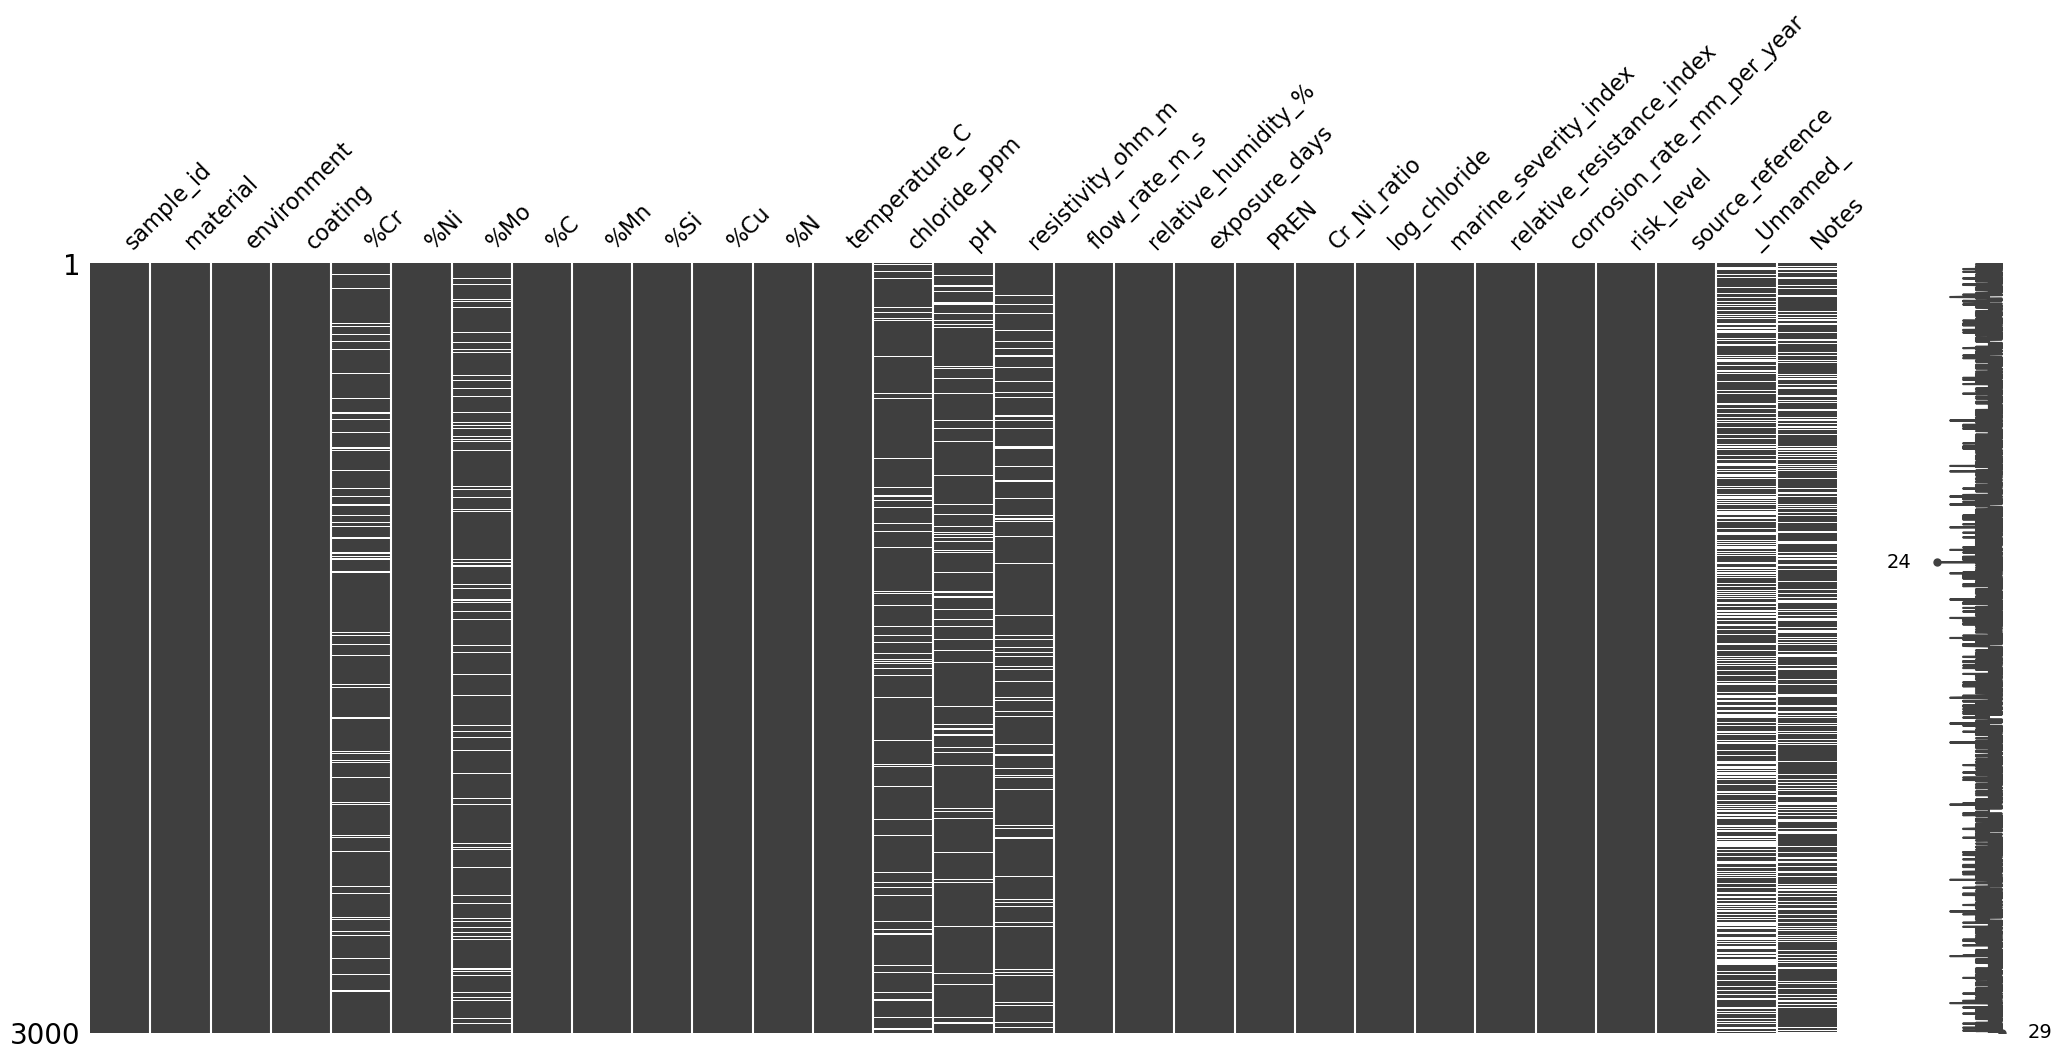

In [ ]:
msno.matrix(df)


# Filling the missed data (skewed data so use median)

In [ ]:


df['%Cr'] = df['%Cr'].replace(r'^\s*$', np.nan, regex=True)
df['%Cr'] = pd.to_numeric(df['%Cr'], errors='coerce')





In [ ]:
num_cols = ['%Cr', '%Mo', 'pH', 'chloride_ppm', 'resistivity_ohm_m']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [ ]:
cat_cols = ['environment', 'coating']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


Fix Invalid / Inconsistent Values

In [ ]:
df['environment'] = df['environment'].replace({
    'marin': 'Marine',
    'soill': 'Soil',
    'atmosph': 'Atmospheric',
    'cementt': 'Cementitious'
})


In [ ]:
df = df[(df['%Cr'] > 0) & (df['%Mo'] >= 0) & (df['%Ni'] >= 0)]


<Axes: xlabel='corrosion_rate_mm_per_year'>

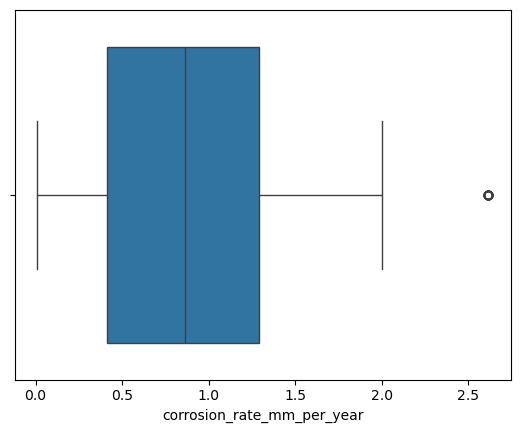

In [ ]:
df['corrosion_rate_mm_per_year'] = np.clip(df['corrosion_rate_mm_per_year'], 0, 2.616)
sns.boxplot(x=df['corrosion_rate_mm_per_year'])



Next Step — Verify Numeric Data Types

In [ ]:
num_cols = df.select_dtypes(include='object').columns
for col in num_cols:
    try:
        df[col] = df[col].astype(float)
    except:
        pass


DROP DUPLICATES


In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
print(df.shape)
print(df.isna().sum())
print(df['corrosion_rate_mm_per_year'].describe())



(2980, 29)
sample_id                       0
material                        0
environment                     0
coating                         0
%Cr                             0
%Ni                             0
%Mo                             0
%C                              0
%Mn                             0
%Si                             0
%Cu                             0
%N                              0
temperature_C                   0
chloride_ppm                    0
pH                              0
resistivity_ohm_m               0
flow_rate_m_s                   0
relative_humidity_%             0
exposure_days                   0
PREN                            0
Cr_Ni_ratio                     0
log_chloride                    0
marine_severity_index           0
relative_resistance_index       0
corrosion_rate_mm_per_year      0
risk_level                      0
source_reference                0
_Unnamed_                     975
Notes                         742
dty

In [ ]:
df.to_excel("Corrosion_Cleaned_Final.xlsx", index=False)


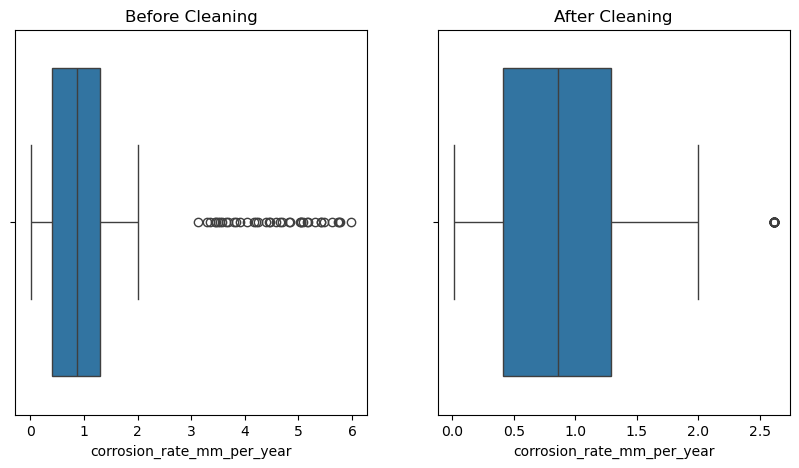

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

sns.boxplot(x=raw_df['corrosion_rate_mm_per_year'], ax=ax[0])
sns.boxplot(x=df['corrosion_rate_mm_per_year'], ax=ax[1])
ax[0].set_title("Before Cleaning")
ax[1].set_title("After Cleaning")
plt.show()
